<a href="https://colab.research.google.com/github/Thinujan-Thillaiselvan/ME320/blob/main/ompetency_Assessment_Quiz_on_Describing_Motion_in_non_Inertial_Frames_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.

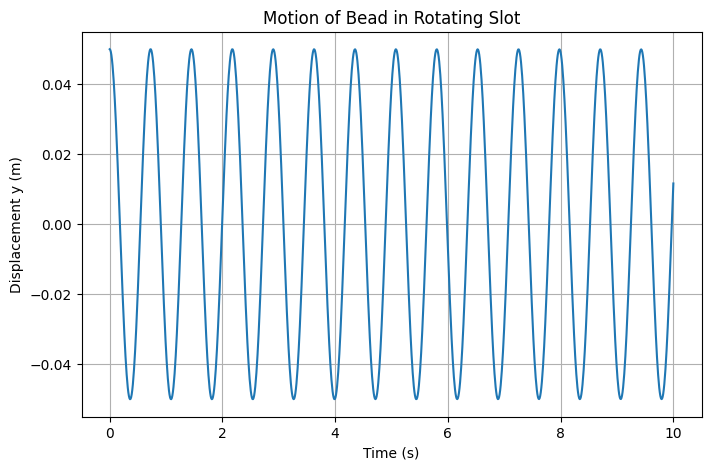

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parameters
m = 0.5      # Mass of bead (kg)
k = 50       # Spring stiffness (N/m)
Omega = 5    # Angular velocity (rad/s)

# State-space model
def bead_system(t, X):
    y = X[0]
    y_dot = X[1]

    y_ddot = -(k/m - Omega**2) * y

    return [y_dot, y_ddot]

# Initial conditions
y0 = 0.05      # Initial displacement (m)
ydot0 = 0.0    # Initial velocity (m/s)

X0 = [y0, ydot0]

# Time span
t_span = (0, 10)
t_eval = np.linspace(0, 10, 1000)

# Numerical solution
sol = solve_ivp(
    bead_system,
    t_span,
    X0,
    t_eval=t_eval
)

# Plot displacement
plt.figure(figsize=(8,5))
plt.plot(sol.t, sol.y[0])
plt.xlabel('Time (s)')
plt.ylabel('Displacement y (m)')
plt.title('Motion of Bead in Rotating Slot')
plt.grid(True)
plt.show()

2.

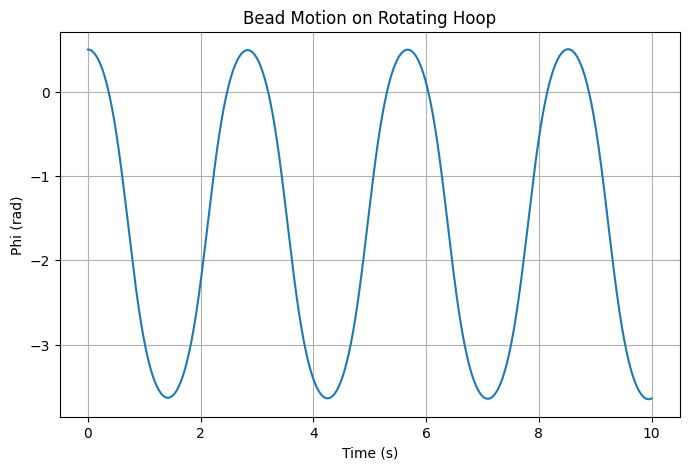

In [3]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parameters
g = 9.81
r = 1.0
Omega = 2.0

# State-space model
def bead_hoop(t, X):
    phi = X[0]
    phi_dot = X[1]

    phi_ddot = Omega**2*np.sin(phi)*np.cos(phi) - (g/r)*np.cos(phi)

    return [phi_dot, phi_ddot]

# Initial conditions
X0 = [0.5, 0.0]

# Time range
t_eval = np.linspace(0, 10, 1000)

sol = solve_ivp(
    bead_hoop,
    [0,10],
    X0,
    t_eval=t_eval
)

# Plot
plt.figure(figsize=(8,5))
plt.plot(sol.t, sol.y[0])
plt.xlabel('Time (s)')
plt.ylabel('Phi (rad)')
plt.title('Bead Motion on Rotating Hoop')
plt.grid(True)
plt.show()

3.

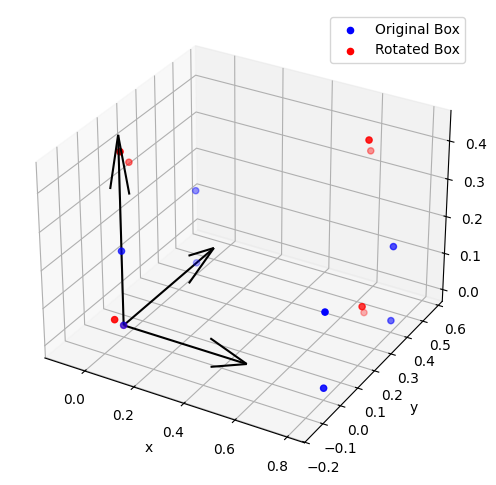

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Box dimensions
l = 0.8
w = 0.4
h = 0.2

# Vertices of box
P = np.array([
    [0,0,0],
    [l,0,0],
    [l,w,0],
    [0,w,0],
    [0,0,h],
    [l,0,h],
    [l,w,h],
    [0,w,h]
])

# Rotation angles
theta1 = np.pi/3
theta3 = np.pi/6

# Rotation about x-axis
R1 = np.array([
    [1,0,0],
    [0,np.cos(theta1),-np.sin(theta1)],
    [0,np.sin(theta1), np.cos(theta1)]
])

# Rotation about z-axis
R3 = np.array([
    [np.cos(theta3),-np.sin(theta3),0],
    [np.sin(theta3), np.cos(theta3),0],
    [0,0,1]
])

# Combined rotation
R = R3 @ R1

# Rotated vertices
P_rot = (R @ P.T).T

# Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Original box vertices
ax.scatter(P[:,0],P[:,1],P[:,2],
           color='blue',label='Original Box')

# Rotated box vertices
ax.scatter(P_rot[:,0],P_rot[:,1],P_rot[:,2],
           color='red',label='Rotated Box')

# Draw coordinate frame
ax.quiver(0,0,0,0.5,0,0,color='k')
ax.quiver(0,0,0,0,0.5,0,color='k')
ax.quiver(0,0,0,0,0,0.5,color='k')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

ax.legend()
plt.show()

4.